# Predicción del riesgo de mortalidad en UCI cardiovascular (pediátrica)

**Objetivo del notebook:** preparar el conjunto de datos final para el entrenamiento de modelos predictivos, abordando explícitamente el desbalance presente en las variables objetivo y definiendo la estrategia de partición de los datos.

En este notebook realizaremos:

- Carga del dataset clínico limpio e imputado.
- Análisis del desbalance de las variables objetivo.
- Justificación clínica y estadística del tratamiento del desbalance.
- Aplicación de técnicas de balanceo (oversampling, undersampling o generación sintética).
- Definición de la estrategia de partición de los datos (entrenamiento, validación y prueba).
- Verificación de que el balanceo se aplique únicamente sobre el conjunto de entrenamiento.
- Exportación de los conjuntos finales listos para el modelado.

Esta etapa es **crítica** para evitar sesgos en los modelos predictivos:
- El balanceo se aplica **ÚNICAMENTE** al conjunto de entrenamiento
- El conjunto de prueba mantiene la distribución real de clases para evaluación honesta
- La estratificación garantiza proporciones similares en train y test
- Los resultados reflejarán condiciones reales del entorno clínico pediátrico

In [1]:
%pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\USUARIO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import RandomUnderSampler

import matplotlib.pyplot as plt
import seaborn as sns
import json

# Configurar estilo de visualizaciones
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

## CARGAR DATASET LIMPIO

In [3]:
print("=" * 80)
print("📊 PREPARACIÓN DE DATOS: CODIFICACIÓN, ESCALADO, BALANCEO Y EXPORTACIÓN")
print("=" * 80)

# Cargar el dataset limpio del notebook anterior
df_clean = pd.read_excel('../data/datasets/dataset_limpio.xlsx')

print(f"\n✅ Dataset limpio cargado exitosamente")
print(f"   - Dimensiones: {df_clean.shape[0]} registros × {df_clean.shape[1]} características")

# Mostrar información básica
print(f"\n📋 Información del dataset:")
print(f"   - Columnas numéricas: {len(df_clean.select_dtypes(include=[np.number]).columns)}")
print(f"   - Columnas categóricas: {len(df_clean.select_dtypes(include=['object']).columns)}")
print(f"   - Valores nulos: {df_clean.isnull().sum().sum()}")

print(f"\nPrimeras 5 filas:")
df_clean.head()

📊 PREPARACIÓN DE DATOS: CODIFICACIÓN, ESCALADO, BALANCEO Y EXPORTACIÓN

✅ Dataset limpio cargado exitosamente
   - Dimensiones: 699 registros × 463 características

📋 Información del dataset:
   - Columnas numéricas: 428
   - Columnas categóricas: 28
   - Valores nulos: 1297

Primeras 5 filas:


,SEXO,Peso,Talla,IMC,Valoración por nutrición,Fecha de Admisión,Fecha Ingreso UCIPCV,Días des de ingreso hasta UCI,Fecha Egreso Vivo,Estancia UCIPCV,...,Dx_Princ_SINDROME_DE_HIPOPLASIA_DEL_COR,Dx_Princ_SITUS_INVERSUS,Dx_Princ_SUBAGUDA,Dx_Princ_SUS_CONEXIONES,"Dx_Princ_SUS_CONEXIONES,_NO_ESPECIFICAD",Dx_Princ_TETRALOGIA_DE_FALLOT,Dx_Princ_TRANSPOSICION_DE_LOS_GRANDES_V,Dx_Princ_TRONCO_ARTERIOSO_COMUN,Dx_Princ_TUMOR_MALIGNO_DEL_CORAZON,Dx_Princ_VENTRICULO_CON_DOBLE_ENTRADA
0,M,10.5,82.800000,15.315410,No,2020-01-14,2020-01-14,0.0,2020-01-17,1.055243,...,0,0,0,0,0,0,0,0,0,0
1,F,29.0,133.000000,16.390000,No,2020-01-10,2020-01-10,0.0,2020-01-14,3.430532,...,0,0,0,0,0,0,0,0,0,0
2,M,4.6,57.500000,13.913043,Sí,2020-01-13,2020-01-13,0.0,2020-01-21,7.218252,...,0,0,0,0,0,0,0,0,0,0
3,M,4.6,57.500000,13.913043,Sí,2020-01-13,2020-01-13,0.0,2020-01-21,7.218252,...,0,0,0,0,0,0,0,0,0,0
4,M,17.0,95.715452,18.556019,Sí,2020-01-09,2020-01-09,0.0,2020-01-12,3.157083,...,0,0,0,0,0,0,0,0,0,0


## ANÁLISIS DE IMPORTANCIA DE VARIABLES

🎯 IDENTIFICANDO VARIABLE OBJETIVO
✅ Variable objetivo identificada: 'Mortalidad'
   Valores únicos: ['no murio' 'murió despues de 30 dias' 'murió en los primeros 30 dias']
   Distribución:
Mortalidad
no murio                         633
murió en los primeros 30 dias     52
murió despues de 30 dias          14
Name: count, dtype: int64

🔍 ANÁLISIS DE IMPORTANCIA DE VARIABLES Y CORRELACIÓN CON TARGET

📊 PASO 1: ANÁLISIS DE CORRELACIÓN (solo variables numéricas)
--------------------------------------------------------------------------------
✓ Variables numéricas encontradas: 428

⚠️  'Mortalidad' no es numérico, se codificará temporalmente...

📈 Top 15 variables más correlacionadas con 'Mortalidad':
--------------------------------------------------------------------------------
 1. Dx_Quirurgico_CIA                             :  0.1265  ██████
 2. Dx_Quirurgico_CIV                             :  0.0975  ████
 3. EDAD_AÑOS                                     :  0.0969  ████
 4. Dx_Quiru

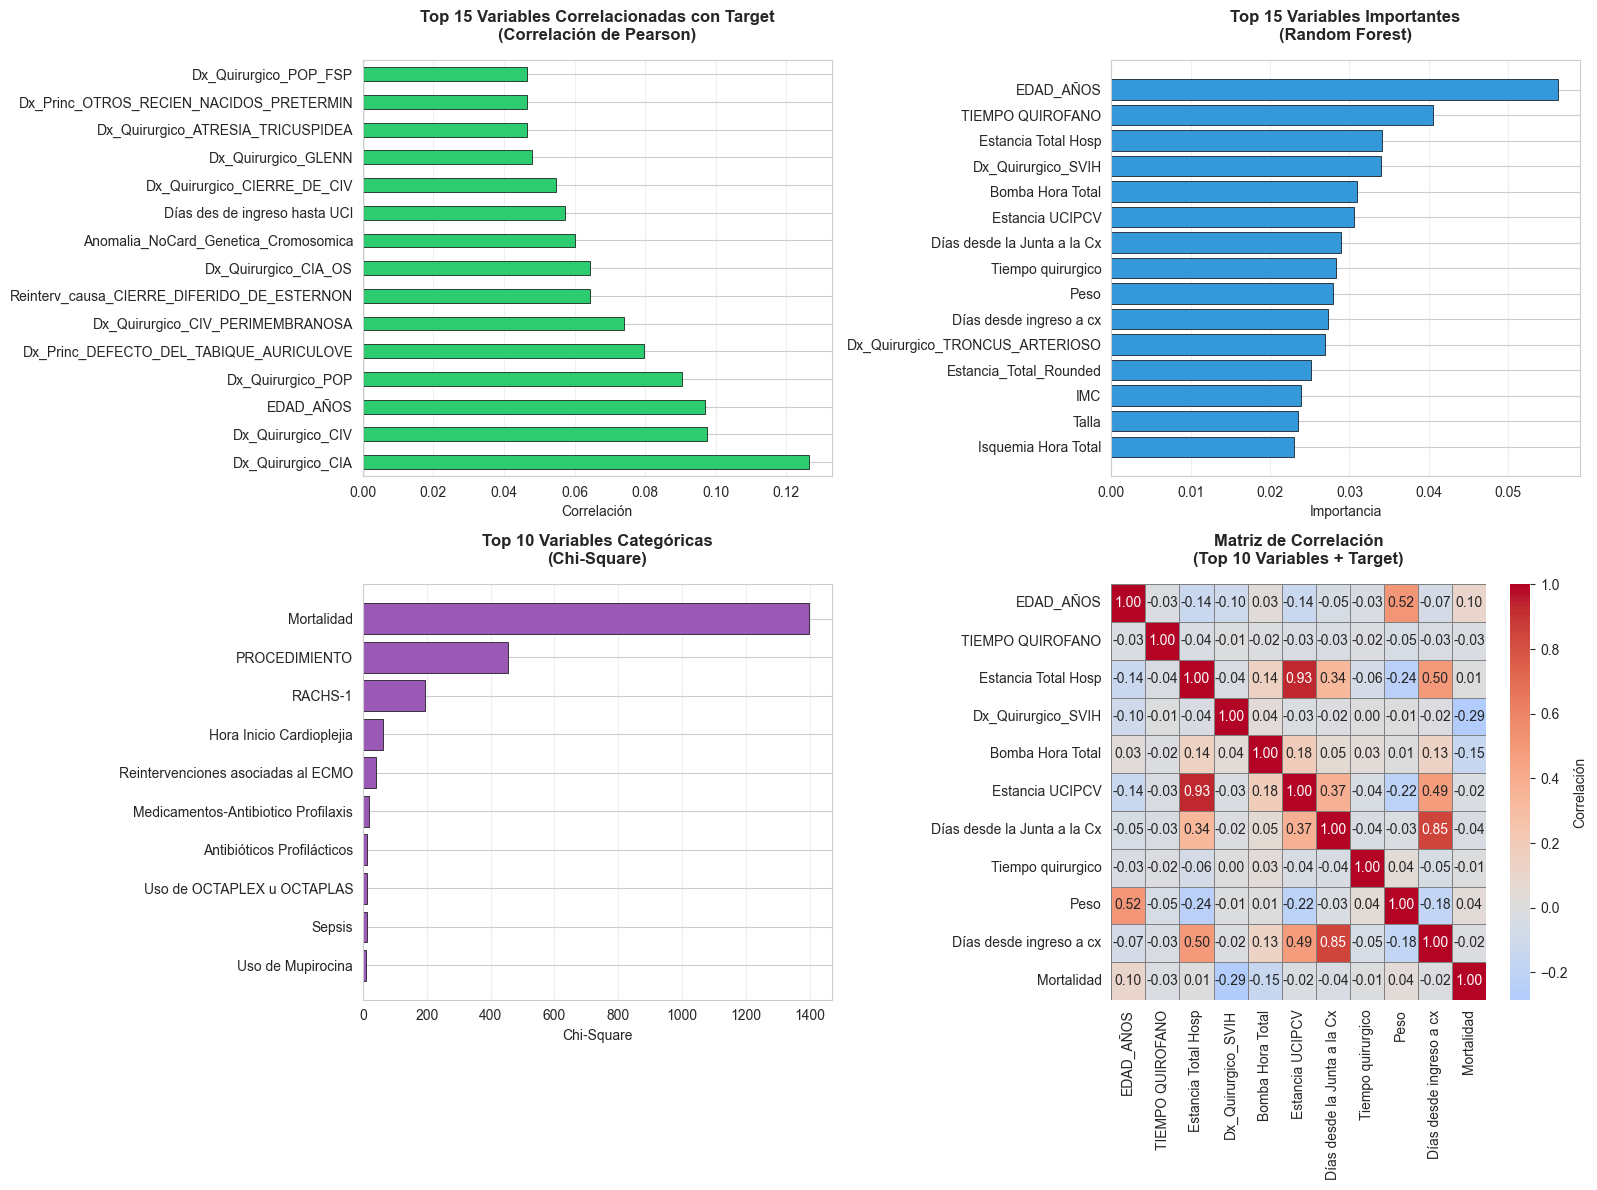

   ✅ Visualizaciones generadas


📋 RESUMEN Y RECOMENDACIONES

✅ Top 10 variables RECOMENDADAS para el modelo:
--------------------------------------------------------------------------------
 1. EDAD_AÑOS                                     (Importancia: 0.0562)
 2. TIEMPO QUIROFANO                              (Importancia: 0.0406)
 3. Estancia Total Hosp                           (Importancia: 0.0341)
 4. Dx_Quirurgico_SVIH                            (Importancia: 0.0340)
 5. Bomba Hora Total                              (Importancia: 0.0310)
 6. Estancia UCIPCV                               (Importancia: 0.0306)
 7. Días desde la Junta a la Cx                   (Importancia: 0.0289)
 8. Tiempo quirurgico                             (Importancia: 0.0283)
 9. Peso                                          (Importancia: 0.0279)
10. Días desde ingreso a cx                       (Importancia: 0.0273)

💡 Variables categóricas significativas (p < 0.05):
-------------------------------------

In [4]:
print("=" * 80)
print("🎯 IDENTIFICANDO VARIABLE OBJETIVO")
print("=" * 80)

target_col = None
for col in df_clean.columns:
    if 'Mortalidad' in col:
        target_col = col
        break

if target_col:
    print(f"✅ Variable objetivo identificada: '{target_col}'")
    print(f"   Valores únicos: {df_clean[target_col].unique()}")
    print(f"   Distribución:")
    print(df_clean[target_col].value_counts())
else:
    print("❌ Variable objetivo NO encontrada")
    raise ValueError("No se encontró columna con 'Mortalidad'")

# ============================================================================
# ANÁLISIS DE IMPORTANCIA DE VARIABLES
# ============================================================================

print("\n" + "=" * 80)
print("🔍 ANÁLISIS DE IMPORTANCIA DE VARIABLES Y CORRELACIÓN CON TARGET")
print("=" * 80)

from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier

# ============================================================================
# 1. CORRELACIÓN NUMÉRICA CON EL TARGET
# ============================================================================

print(f"\n📊 PASO 1: ANÁLISIS DE CORRELACIÓN (solo variables numéricas)")
print("-" * 80)

# Seleccionar solo columnas numéricas
numeric_data = df_clean.select_dtypes(include=[np.number]).copy()

print(f"✓ Variables numéricas encontradas: {len(numeric_data.columns)}")

# ✅ VERSIÓN CORREGIDA: Verificar si el target está en numeric_data
if target_col in numeric_data.columns:
    # Target es numérico → calcular correlación directamente
    correlacion_target = numeric_data.corr()[target_col].sort_values(ascending=False)
    
    print(f"\n📈 Top 15 variables más correlacionadas con '{target_col}':")
    print("-" * 80)
    
    contador = 0
    for variable, corr in correlacion_target.items():
        if variable != target_col:  # Excluir el target mismo
            contador += 1
            # Barra visual
            strength = abs(corr)
            barra = "█" * int(strength * 50)
            print(f"{contador:2d}. {variable:45s} : {corr:7.4f}  {barra}")
            if contador >= 15:
                break
else:
    # Target es texto → crear una versión numérica temporal
    from sklearn.preprocessing import LabelEncoder
    
    print(f"\n⚠️  '{target_col}' no es numérico, se codificará temporalmente...")
    
    # Crear copia temporal con target codificado
    numeric_data_with_target = numeric_data.copy()
    
    y_raw = df_clean[target_col].copy()
    if y_raw.dtype == 'object':
        le = LabelEncoder()
        numeric_data_with_target[target_col] = le.fit_transform(y_raw.astype(str))
    
    # Ahora calcular correlación
    correlacion_target = numeric_data_with_target.corr()[target_col].sort_values(ascending=False)
    
    print(f"\n📈 Top 15 variables más correlacionadas con '{target_col}':")
    print("-" * 80)
    
    contador = 0
    for variable, corr in correlacion_target.items():
        if variable != target_col:  # Excluir el target mismo
            contador += 1
            # Barra visual
            strength = abs(corr)
            barra = "█" * int(strength * 50)
            print(f"{contador:2d}. {variable:45s} : {corr:7.4f}  {barra}")
            if contador >= 15:
                break

# ============================================================================
# 2. IMPORTANCIA CON RANDOM FOREST
# ============================================================================

print(f"\n\n🌳 PASO 2: IMPORTANCIA DE VARIABLES CON RANDOM FOREST")
print("-" * 80)

# 🔍 DEBUG: Ver qué columnas numéricas tenemos
print(f"\n🔍 Columnas numéricas encontradas: {len(numeric_data.columns)}")
print(f"🔍 ¿Target '{target_col}' está en numeric_data? {target_col in numeric_data.columns}")

# ✅ VERSIÓN CORREGIDA: Manejar ambos casos
if target_col in numeric_data.columns:
    # Caso 1: Target es numérico
    X_numeric = numeric_data.drop(columns=[target_col])
    y_numeric = numeric_data[target_col]
else:
    # Caso 2: Target es texto (necesita codificación)
    from sklearn.preprocessing import LabelEncoder
    
    X_numeric = numeric_data.copy()
    
    # Codificar el target del df_clean original
    y_raw = df_clean[target_col].copy()
    
    if y_raw.dtype == 'object':
        le = LabelEncoder()
        y_numeric = le.fit_transform(y_raw.astype(str))
        print(f"\n✓ Target codificado: {dict(zip(le.classes_, le.transform(le.classes_)))}")
    else:
        y_numeric = y_raw

print(f"✓ Features numéricas: {X_numeric.shape[1]}")
print(f"✓ Muestras: {X_numeric.shape[0]}")

# Entrenar Random Forest rápido
print(f"\n🔄 Entrenando Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1, 
    max_depth=10,
    verbose=0
)
rf_model.fit(X_numeric, y_numeric)

# Obtener importancia
feature_importance = pd.DataFrame({
    'variable': X_numeric.columns,
    'importancia': rf_model.feature_importances_
}).sort_values('importancia', ascending=False)

print(f"✅ Random Forest entrenado\n")
print(f"🏆 Top 15 variables más importantes (Random Forest):")
print("-" * 80)

for i, (idx, row) in enumerate(feature_importance.head(15).iterrows(), 1):
    barra = "█" * int(row['importancia'] * 200)
    print(f"{i:2d}. {row['variable']:45s} : {row['importancia']:.4f}  {barra}")

# ============================================================================
# 3. ANÁLISIS DE VARIABLES CATEGÓRICAS
# ============================================================================

print(f"\n\n📊 PASO 3: ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("-" * 80)

categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f"✓ Variables categóricas encontradas: {len(categorical_cols)}")

# Chi-square test para variables categóricas
chi_results = []

print(f"\n🔄 Calculando Chi-Square test...")

for col in categorical_cols:
    try:
        contingency_table = pd.crosstab(df_clean[col], df_clean[target_col])
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        chi_results.append({
            'variable': col,
            'chi2': chi2,
            'p_value': p_value,
            'significancia': 'Sí' if p_value < 0.05 else 'No'
        })
    except Exception as e:
        print(f"   ⚠️  Error procesando {col}: {str(e)}")
        pass

chi_df = pd.DataFrame(chi_results).sort_values('chi2', ascending=False)

print(f"\n📈 Variables categóricas vs Target (Chi-Square test):")
print("-" * 80)

for i, (idx, row) in enumerate(chi_df.iterrows(), 1):
    sig_symbol = "✅" if row['significancia'] == 'Sí' else "❌"
    print(f"{i:2d}. {row['variable']:45s} : χ²={row['chi2']:8.2f}  p-value={row['p_value']:.6f}  {sig_symbol}")

# ============================================================================
# 4. VISUALIZACIÓN
# ============================================================================

print(f"\n\n📊 PASO 4: GENERANDO VISUALIZACIONES")
print("-" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Correlación con target (top 15)
print("   📈 Gráfico 1: Correlación con Target...")
top_corr = correlacion_target.drop(target_col).head(15)
ax1 = axes[0, 0]
colors_corr = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_corr.values]
top_corr.plot(kind='barh', ax=ax1, color=colors_corr, edgecolor='black', linewidth=0.5)
ax1.set_title('Top 15 Variables Correlacionadas con Target\n(Correlación de Pearson)', 
              fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Correlación', fontsize=10)
ax1.grid(axis='x', alpha=0.3)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

# Gráfico 2: Importancia Random Forest (top 15)
print("   📈 Gráfico 2: Importancia Random Forest...")
ax2 = axes[0, 1]
top_rf = feature_importance.head(15)
ax2.barh(range(len(top_rf)), top_rf['importancia'].values, color='#3498db', edgecolor='black', linewidth=0.5)
ax2.set_yticks(range(len(top_rf)))
ax2.set_yticklabels(top_rf['variable'].values)
ax2.set_title('Top 15 Variables Importantes\n(Random Forest)', 
              fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel('Importancia', fontsize=10)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

# Gráfico 3: Chi-Square para variables categóricas (top 10)
print("   📈 Gráfico 3: Chi-Square Variables Categóricas...")
ax3 = axes[1, 0]
top_chi = chi_df.head(10)
ax3.barh(range(len(top_chi)), top_chi['chi2'].values, color='#9b59b6', edgecolor='black', linewidth=0.5)
ax3.set_yticks(range(len(top_chi)))
ax3.set_yticklabels(top_chi['variable'].values)
ax3.set_title('Top 10 Variables Categóricas\n(Chi-Square)', 
              fontsize=12, fontweight='bold', pad=15)
ax3.set_xlabel('Chi-Square', fontsize=10)
ax3.grid(axis='x', alpha=0.3)
ax3.invert_yaxis()

# Gráfico 4: Matriz de correlación (top variables numéricas)
print("   📈 Gráfico 4: Matriz de Correlación...")
top_variables = feature_importance.head(10)['variable'].tolist()

# ✅ VERSIÓN CORREGIDA: Usar numeric_data_with_target si existe
if target_col in numeric_data.columns:
    # Target es numérico y está en numeric_data
    correlation_matrix = numeric_data[top_variables + [target_col]].corr()
else:
    # Target es texto → usar la versión codificada que creamos en PASO 1
    # Recrear numeric_data_with_target si no existe
    if 'numeric_data_with_target' not in locals():
        from sklearn.preprocessing import LabelEncoder
        numeric_data_with_target = numeric_data.copy()
        y_raw = df_clean[target_col].copy()
        if y_raw.dtype == 'object':
            le = LabelEncoder()
            numeric_data_with_target[target_col] = le.fit_transform(y_raw.astype(str))
    
    correlation_matrix = numeric_data_with_target[top_variables + [target_col]].corr()

ax4 = axes[1, 1]
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax4, cbar_kws={'label': 'Correlación'}, 
            linewidths=0.5, linecolor='gray')
ax4.set_title('Matriz de Correlación\n(Top 10 Variables + Target)', 
              fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print("   ✅ Visualizaciones generadas")

# ============================================================================
# 5. RESUMEN Y RECOMENDACIONES
# ============================================================================

print(f"\n\n📋 RESUMEN Y RECOMENDACIONES")
print("=" * 80)

print(f"\n✅ Top 10 variables RECOMENDADAS para el modelo:")
print("-" * 80)

top_10_vars = feature_importance.head(10)['variable'].tolist()
for i, var in enumerate(top_10_vars, 1):
    imp = feature_importance[feature_importance['variable'] == var]['importancia'].values[0]
    print(f"{i:2d}. {var:45s} (Importancia: {imp:.4f})")

print(f"\n💡 Variables categóricas significativas (p < 0.05):")
print("-" * 80)

significant_cat = chi_df[chi_df['significancia'] == 'Sí']
if len(significant_cat) > 0:
    for i, (idx, row) in enumerate(significant_cat.head(10).iterrows(), 1):
        print(f"{i:2d}. {row['variable']:45s} (χ²={row['chi2']:8.2f})")
else:
    print("   ⚠️  No hay variables categóricas significativas")

print(f"\n⚠️  Variables con baja importancia (podrían excluirse):")
print("-" * 80)

low_importance = feature_importance.tail(10)
for i, (idx, row) in enumerate(low_importance.iterrows(), 1):
    print(f"{i:2d}. {row['variable']:45s} (Importancia: {row['importancia']:.4f})")

print(f"\n✅ Análisis de importancia completado")
print("=" * 80)

## CODIFICACIÓN DE VARIABLES CATEGORICAS

Después de analizar todas las variables categóricas, se encontró que **ninguna es ordinal** a excepción de la variable `ASA`.

- **ASA**: Esta variable tiene un orden natural (I, II, III, IV, V) que representa niveles crecientes de riesgo, por lo que se utilizará **Label Encoding** para preservar esta relación ordinal.

- **Resto de variables categóricas**: Todas las demás variables categóricas son nominales (sin orden inherente), por lo que se utilizará **One-Hot Encoding** para convertirlas en variables binarias.

In [5]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

variables_categoricas = [
    'SEXO',
    'DIAGNÓSTICO QUIRURGICO',
    'Dx Principal',
    'Anomalias no Cardiacas Mayores',
    'Prematuridad',
    'PROCEDIMIENTO',
    'RACHS-1',
    'ASA',
    'CEC',
    'CLAMP',
    'ARRESTO CIRCULATORIO',
    'Uso de OCTAPLEX u OCTAPLAS',
    'Antibióticos Profilácticos',
    'Medicamentos-Antibiotico Profilaxis',
    'Uso de Mupirocina',
    'Ventilación Mecanica',
    'Tipo Ventilación Mecanica',
    'ECMO',
    'Reintervenciones asociadas al ECMO',
    'Reintervención Qx',
    'Causa de Reintervención',
    'Número de reintervenciones',
    'ISO',
    'Arritmias',
    'Sepsis',
    'Disfunción Multiorganica',
    'Sangrado',
    'Uso de Hemoderivados en el Episodio',
    'Valoración por nutrición',
    'Junta Medica',
]

# POR EL MOMENTO DEBIDO A QUE ES FORMATE DATETIME
df_clean=df_clean.drop(columns=[
    'Hora Inicio Cardioplejia',
    'Fecha de Admisión',
    'Fecha Ingreso UCIPCV',
    'Fecha Egreso Vivo',
    'FECHA CX',
    'Fecha Junta Medica',
    'Fecha Intubación',
    'Fecha Extubación'
])

# POR EL MOMENTO PARA QUE NO DE PROBLEMAS
df_clean=df_clean.drop(columns=[
    'Días desde la Junta a la Cx',
    'Estancia UCIPCV',
    'Días des de ingreso hasta UCI',
    'Días desde ingreso a cx'
])

# ✅ CODIFICACIÓN SEPARADA PARA TARGET
target_col = None
for col in df_clean.columns:
    if 'Mortalidad' in col:
        target_col = col
        break

print(f"✓ Variable objetivo identificada: '{target_col}'")

# 🔧 CODIFICAR TARGET (Label Encoding - multiclase)
mapeo_mortalidad = {
    'no murio': 0,
    'murió en los primeros 30 dias': 1,
    'murió despues de 30 dias': 2
}

df_clean[target_col] = (df_clean[target_col]
                        .astype(str)
                        .str.strip()
                        .str.lower()
                        .map(mapeo_mortalidad))

print(f"✓ {target_col}: Label Encoding")


# Label Encoding para ASA (ordinal)
variable_ordinal = 'ASA'
if variable_ordinal in df_clean.columns:
    le = LabelEncoder()
    df_clean[f'{variable_ordinal}_encoded'] = le.fit_transform(df_clean[variable_ordinal].astype(str))
    print(f"\n✓ {variable_ordinal}: Label Encoding")
    print(f"  Mapeo: {dict(zip(le.classes_, le.transform(le.classes_)))}")
    # Eliminar la columna original
    df_clean = df_clean.drop(columns=[variable_ordinal])

# Redefinir variables_nominales DESPUÉS de eliminar ASA
variables_nominales = [var for var in variables_categoricas if var != variable_ordinal and var in df_clean.columns]

print("Codificación de variables categóricas:")
print("=" * 60)

# One-Hot Encoding para variables nominales
if len(variables_nominales) > 0:
    # Usar prefix como string, no como lista
    df_encoded = pd.get_dummies(df_clean[variables_nominales], prefix='cat', drop_first=False)
    # Eliminar las columnas originales
    df_clean = df_clean.drop(columns=variables_nominales)
    # Concatenar las columnas codificadas
    df_clean = pd.concat([df_clean, df_encoded], axis=1)
    print(f"\n✓ Variables nominales ({len(variables_nominales)}): One-Hot Encoding")
    print(f"  Variables codificadas: {', '.join(variables_nominales[:5])}{'...' if len(variables_nominales) > 5 else ''}")

print(f"\n✅ Codificación completada")
print(f"Dimensiones del DataFrame después de la codificación: {df_clean.shape}")
print(f"✓ Variable objetivo sigue siendo: '{target_col}'")

✓ Variable objetivo identificada: 'Mortalidad'
✓ Mortalidad: Label Encoding

✓ ASA: Label Encoding
  Mapeo: {'I': np.int64(0), 'II': np.int64(1), 'III': np.int64(2), 'IV': np.int64(3)}
Codificación de variables categóricas:

✓ Variables nominales (25): One-Hot Encoding
  Variables codificadas: SEXO, Prematuridad, PROCEDIMIENTO, RACHS-1, CEC...

✅ Codificación completada
Dimensiones del DataFrame después de la codificación: (699, 652)
✓ Variable objetivo sigue siendo: 'Mortalidad'


## APLICAR ESCALADO (StandardScaler)

In [6]:
## APLICAR ESCALADO (StandardScaler)

# Identificar columnas numéricas
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print(f"✓ Variable objetivo identificada: '{target_col}'")
print(f"✓ Columnas numéricas encontradas: {len(numeric_cols)}")

# Remover target de las columnas a escalar
if target_col in numeric_cols:
    numeric_cols.remove(target_col)
    print(f"✓ Variable objetivo EXCLUIDA del escalado")

# MOSTRAR ESTADÍSTICAS ANTES
print(f"\n📊 ESTADÍSTICAS ANTES del escalado:")
print("-" * 60)
print(f"   - Media ANTES: {df_clean[numeric_cols].mean().mean():.6f}")
print(f"   - Desv.Est ANTES: {df_clean[numeric_cols].std().mean():.6f}")
print(f"   - Mín ANTES: {df_clean[numeric_cols].min().min():.6f}")
print(f"   - Máx ANTES: {df_clean[numeric_cols].max().max():.6f}")

# Aplicar StandardScaler
scaler = StandardScaler()
df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

# MOSTRAR ESTADÍSTICAS DESPUÉS
print(f"\n📊 ESTADÍSTICAS DESPUÉS del escalado:")
print("-" * 60)
print(f"✅ Escalado completado")
print(f"   - Columnas escaladas: {len(numeric_cols)}")
print(f"   - Media DESPUÉS: {df_clean[numeric_cols].mean().mean():.6f} (≈ 0) ✅")
print(f"   - Desv.Est DESPUÉS: {df_clean[numeric_cols].std().mean():.6f} (≈ 1) ✅")
print(f"   - Mín DESPUÉS: {df_clean[numeric_cols].min().min():.6f}")
print(f"   - Máx DESPUÉS: {df_clean[numeric_cols].max().max():.6f}")

print(f"\n📈 COMPARACIÓN:")
print("-" * 60)
print(f"   ✅ Media: variable → 0")
print(f"   ✅ Desv.Est: variable → 1")
print(f"   ✅ Datos escalados entre aproximadamente -3 y +3")

✓ Variable objetivo identificada: 'Mortalidad'
✓ Columnas numéricas encontradas: 426
✓ Variable objetivo EXCLUIDA del escalado

📊 ESTADÍSTICAS ANTES del escalado:
------------------------------------------------------------
   - Media ANTES: 1.770129
   - Desv.Est ANTES: 3.612429
   - Mín ANTES: -2128.833333
   - Máx ANTES: 7033.716667

📊 ESTADÍSTICAS DESPUÉS del escalado:
------------------------------------------------------------
✅ Escalado completado
   - Columnas escaladas: 425
   - Media DESPUÉS: -0.000000 (≈ 0) ✅
   - Desv.Est DESPUÉS: 0.972461 (≈ 1) ✅
   - Mín DESPUÉS: -16.663771
   - Máx DESPUÉS: 26.419690

📈 COMPARACIÓN:
------------------------------------------------------------
   ✅ Media: variable → 0
   ✅ Desv.Est: variable → 1
   ✅ Datos escalados entre aproximadamente -3 y +3


In [7]:
## APLICAR ESCALADO (StandardScaler)

# DEBUG: Ver todas las columnas
print(f"\n🔍 DEBUG - Primeras 50 columnas de df_clean:")
print(df_clean.columns[:50].tolist())

# Identificar columnas numéricas
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n✓ Variable objetivo identificada: '{target_col}'")
print(f"✓ Columnas numéricas encontradas: {len(numeric_cols)}")
print(f"🔍 Primeras 10 columnas numéricas: {numeric_cols[:10]}")

# Remover target de las columnas a escalar (VERSIÓN CORREGIDA)
target_cols_to_exclude = [col for col in numeric_cols if 'Mortalidad' in col]
numeric_cols_to_scale = [col for col in numeric_cols if col not in target_cols_to_exclude]

print(f"\n✓ Columnas a EXCLUIR (target): {target_cols_to_exclude}")
print(f"✓ Columnas a ESCALAR: {len(numeric_cols_to_scale)}")

# ...resto del código...


🔍 DEBUG - Primeras 50 columnas de df_clean:
['Peso', 'Talla', 'IMC', 'Estancia Total Hosp', 'Bomba Hora Total', 'Isquemia Hora Total', 'Paro Circulatorio Hora Total', 'Dosis Inicial Cardioplejia', 'Dosis Mantenimiento Cardioplejia', 'Volumen total cardioplejia', 'Tiempo quirurgico', 'TIEMPO QUIROFANO', 'Tiempo de Ventilación Mecanica', 'Días ECMO', 'EDAD_AÑOS', 'Estancia_Total_Rounded', 'Mortalidad', 'Dx_Quirurgico_ACCESO_MITROAORTICO', 'Dx_Quirurgico_ALCAPA', 'Dx_Quirurgico_ANEURISMA_AORTICO', 'Dx_Quirurgico_ANEURISMA_SENO_DE_VALSALVA', 'Dx_Quirurgico_ANILLO_VASCULAR_-_SUDCLAVIA_AB', 'Dx_Quirurgico_ANOMALIA_DE_EBSTEIN', 'Dx_Quirurgico_ANOMALIA_DE_ESBTEIN', 'Dx_Quirurgico_ARCO_ARTICO_DISTAL_HIPOPLASICO', 'Dx_Quirurgico_ARTERIA_SUBCLAVIA_ABERRANTE_IZ', 'Dx_Quirurgico_ATERSIA_TRICUSPIDEA_CON_SOBREF', 'Dx_Quirurgico_ATRESIA_MITRAL', 'Dx_Quirurgico_ATRESIA_PULMONAR', 'Dx_Quirurgico_ATRESIA_PULMONAR_CON_CIV', 'Dx_Quirurgico_ATRESIA_PULMONAR_SEPTUM_INTEGR', 'Dx_Quirurgico_ATRESIA_TRICUSPDEA

## SEPARAR VARIABLE OBJETIVO (X, y)

In [8]:
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]
y = y.map({0: 0, 1: 1, 2: 1})   # clases 1 y 2 → "muere"

print(f"✅ Separación completada")
print(f"   - X (características): {X.shape}")
print(f"   - y (objetivo): {y.shape}")

✅ Separación completada
   - X (características): (699, 651)
   - y (objetivo): (699,)


## DEFINICIÓN DE FEATURES Y TARGET (100% de los datos)

In [9]:
# Sin split — usamos el 100% para entrenamiento y CV
X_train = X
y_train = y

## ANÁLISIS DE DESBALANCE DE CLASES

In [10]:
conteo_antes = y_train.value_counts().sort_index()
porcentajes_antes = (conteo_antes / len(y_train) * 100).round(2)

print(f"\n📊 Distribución ANTES del balanceo (conjunto de entrenamiento):")
print("-" * 80)

max_label_len = max(len(str(c)) for c in conteo_antes.index)

for clase in conteo_antes.index:
    count = conteo_antes[clase]
    pct = porcentajes_antes[clase]
    barra = "█" * int(pct / 3)
    print(f"   {str(clase):<{max_label_len}} : {count:>5d} registros ({pct:>6.2f}%) {barra}")

# Calcular ratio de desbalance
clase_mayoritaria = conteo_antes.max()
clase_minoritaria = conteo_antes.min()
ratio_desbalance = clase_mayoritaria / clase_minoritaria

print(f"\n⚠️  RATIO DE DESBALANCE: {ratio_desbalance:.2f}:1")
print(f"   (La clase mayoritaria es {ratio_desbalance:.1f}x más frecuente)")

# Clasificación del desbalance
if ratio_desbalance < 1.5:
    recomendacion = "BAJO - Métodos estándar pueden funcionar"
    simbolo = "✅"
elif ratio_desbalance < 3:
    recomendacion = "MODERADO - Se recomienda balanceo"
    simbolo = "⚠️"
elif ratio_desbalance < 10:
    recomendacion = "ALTO - Balanceo NECESARIO"
    simbolo = "⚠️"
else:
    recomendacion = "SEVERO - Balanceo CRÍTICO"
    simbolo = "🔴"

print(f"   {simbolo} Nivel de desbalance: {recomendacion}")


📊 Distribución ANTES del balanceo (conjunto de entrenamiento):
--------------------------------------------------------------------------------
   0 :   633 registros ( 90.56%) ██████████████████████████████
   1 :    66 registros (  9.44%) ███

⚠️  RATIO DE DESBALANCE: 9.59:1
   (La clase mayoritaria es 9.6x más frecuente)
   ⚠️ Nivel de desbalance: ALTO - Balanceo NECESARIO


## EXPORTAR DATOS RAW (SIN BALANCEO)

In [11]:
print("\n" + "="*80)
print("📦 VERSIÓN 1: EXPORTANDO DATOS RAW (SIN BALANCEO)")
print("="*80)

os.makedirs('../data/processed', exist_ok=True)

# Guardar en PICKLE
print(f"\n📦 Guardando en formato PICKLE...")

pickle.dump(X_train, open('../data/processed/pickle/X_train_raw.pkl', 'wb'))
pickle.dump(y_train, open('../data/processed/pickle/y_train_raw.pkl', 'wb'))

print(f"   ✅ X_train_raw.pkl - {X_train.shape}")
print(f"   ✅ y_train_raw.pkl - {y_train.shape}")

# Guardar en CSV
print(f"\n📋 Guardando en formato CSV...")

pd.DataFrame(X_train).to_csv('../data/processed/csv/X_train_raw.csv', index=False)
pd.Series(y_train, name=target_col).to_csv('../data/processed/csv/y_train_raw.csv', index=False)

print(f"   ✅ X_train_raw.csv")
print(f"   ✅ y_train_raw.csv")

print(f"\n✅ Datos RAW exportados exitosamente")


📦 VERSIÓN 1: EXPORTANDO DATOS RAW (SIN BALANCEO)

📦 Guardando en formato PICKLE...
   ✅ X_train_raw.pkl - (699, 651)
   ✅ y_train_raw.pkl - (699,)

📋 Guardando en formato CSV...
   ✅ X_train_raw.csv
   ✅ y_train_raw.csv

✅ Datos RAW exportados exitosamente


## BALANCEO - SOLO EN ENTRENAMIENTO

**⚠️ IMPORTANTE:**
- El balanceo se aplica **ÚNICAMENTE** al conjunto de entrenamiento
- El conjunto de prueba **NUNCA** se balancea
- Esto evita **FUGA DE DATOS** (data leakage)
- Los modelos aprenden patrones de clases con distribución alterada
- Pero la evaluación usa datos con distribución real

In [12]:
## BALANCEO CON PROPORCIONES PERSONALIZADAS

print(f"\n🔍 Información de clases ANTES del balanceo:")
print("-" * 80)
conteo_antes = y_train.value_counts().sort_index()
print(conteo_antes)
print(f"Número de clases: {len(conteo_antes)}")

# 🎯 DEFINIR PROPORCIONES PERSONALIZADAS
# Por ejemplo: clase 0 = 70%, clase 1 = 20%, clase 2 = 10%
proporciones_deseadas = {
    0: 0.70,  # 70% de los datos
    1: 0.30,  # 20% de los datos
}

# Calcular el tamaño total deseado
# Usamos la clase mayoritaria como referencia
clase_mayoritaria = conteo_antes.idxmax()
size_mayoritaria = conteo_antes[clase_mayoritaria]

# Calcular el nuevo tamaño total basado en proporciones
# Si clase 0 (mayoritaria) = 70% → tamaño_total = size_mayoritaria / 0.70
tamaño_total_deseado = int(size_mayoritaria / proporciones_deseadas[clase_mayoritaria])

print(f"\n🎯 Estrategia de balanceo (proporciones personalizadas):")
print(f"   - Tamaño total deseado: {tamaño_total_deseado}")
print(f"   - Proporciones deseadas: {proporciones_deseadas}")

# Calcular cuántas muestras de cada clase necesitamos
sampling_strategy = {
    clase: int(tamaño_total_deseado * prop)
    for clase, prop in proporciones_deseadas.items()
    if clase != clase_mayoritaria  # No modificar la clase mayoritaria
}

print(f"   - Muestras objetivo por clase:")
for clase, count in sampling_strategy.items():
    print(f"     Clase {clase}: {count} muestras")

# Aplicar balanceo
adasyn = ADASYN(sampling_strategy=sampling_strategy, random_state=42, n_neighbors=5)

print(f"\n🔧 Aplicando balanceo...")
X_train_balanced, y_train_balanced = adasyn.fit_resample(X_train, y_train)

print(f"✅ Después del balanceo:")
conteo_despues = y_train_balanced.value_counts().sort_index()
print(conteo_despues)

# Estadísticas finales
porcentajes_antes = (y_train.value_counts().sort_index() / len(y_train) * 100).round(2)
porcentajes_despues = (conteo_despues / len(y_train_balanced) * 100).round(2)

print(f"\n📊 Distribución ANTES del balanceo:")
print("-" * 80)

max_label_len = max(len(str(c)) for c in y_train.value_counts().index)

for clase in y_train.value_counts().sort_index().index:
    count = y_train.value_counts()[clase]
    pct = porcentajes_antes[clase]
    barra = "█" * int(pct / 3)
    print(f"   {str(clase):<{max_label_len}} : {count:>5d} registros ({pct:>6.2f}%) {barra}")

print(f"\n📊 Distribución DESPUÉS del balanceo (proporciones personalizadas):")
print("-" * 80)

for clase in conteo_despues.index:
    count = conteo_despues[clase]
    pct = porcentajes_despues[clase]
    barra = "█" * int(pct / 3)
    print(f"   {str(clase):<{max_label_len}} : {count:>5d} registros ({pct:>6.2f}%) {barra}")

# Calcular ratios
ratio_antes = y_train.value_counts().max() / y_train.value_counts().min()
ratio_despues = conteo_despues.max() / conteo_despues.min()

print(f"\n✅ Nuevo ratio de desbalance: {ratio_despues:.2f}:1 (antes era {ratio_antes:.2f}:1)")

print(f"\n✅ Balanceo completado con proporciones personalizadas")
print(f"   - Entrenamiento balanceado: {X_train_balanced.shape}")
print(f"   - Muestras AÑADIDAS: {X_train_balanced.shape[0] - X_train.shape[0]}")


🔍 Información de clases ANTES del balanceo:
--------------------------------------------------------------------------------
Mortalidad
0    633
1     66
Name: count, dtype: int64
Número de clases: 2

🎯 Estrategia de balanceo (proporciones personalizadas):
   - Tamaño total deseado: 904
   - Proporciones deseadas: {0: 0.7, 1: 0.3}
   - Muestras objetivo por clase:
     Clase 1: 271 muestras

🔧 Aplicando balanceo...
✅ Después del balanceo:
Mortalidad
0    633
1    265
Name: count, dtype: int64

📊 Distribución ANTES del balanceo:
--------------------------------------------------------------------------------
   0 :   633 registros ( 90.56%) ██████████████████████████████
   1 :    66 registros (  9.44%) ███

📊 Distribución DESPUÉS del balanceo (proporciones personalizadas):
--------------------------------------------------------------------------------
   0 :   633 registros ( 70.49%) ███████████████████████
   1 :   265 registros ( 29.51%) █████████

✅ Nuevo ratio de desbalance: 2.39

## VISUALIZACIÓN DEL BALANCEO

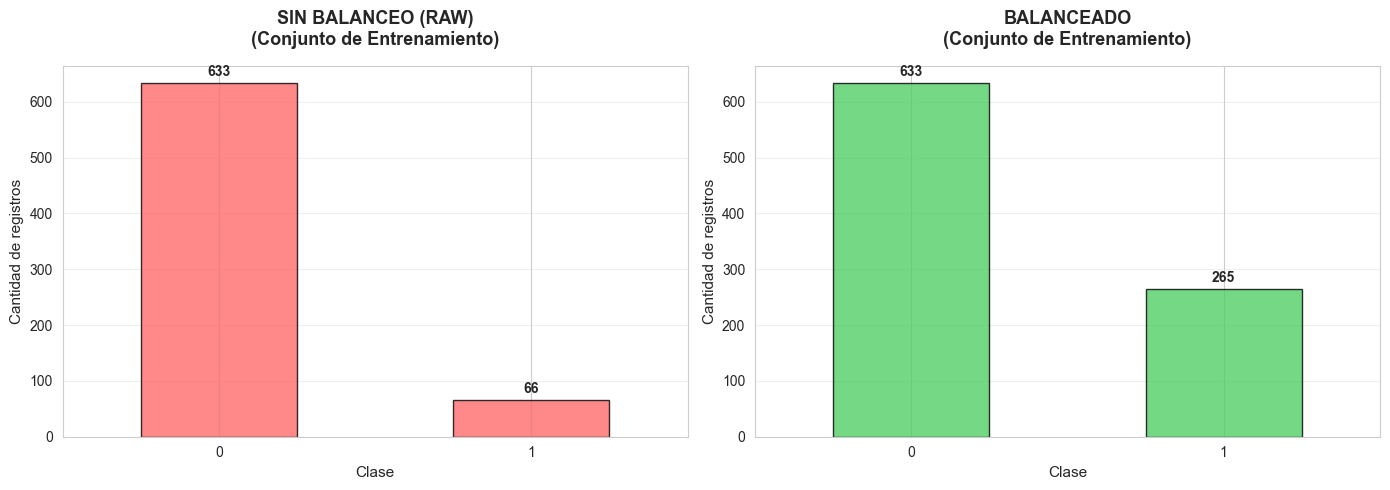

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: SIN BALANCEO (RAW)
conteo_antes.plot(kind='bar', ax=axes[0], color='#ff6b6b', alpha=0.8, edgecolor='black')
axes[0].set_title('SIN BALANCEO (RAW)\n(Conjunto de Entrenamiento)', 
                  fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Cantidad de registros', fontsize=11)
axes[0].set_xlabel('Clase', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

for i, v in enumerate(conteo_antes):
    axes[0].text(i, v + max(conteo_antes)*0.02, str(v), ha='center', fontweight='bold')

# Gráfico 2: balanceado
conteo_despues.plot(kind='bar', ax=axes[1], color='#51cf66', alpha=0.8, edgecolor='black')
axes[1].set_title('BALANCEADO\n(Conjunto de Entrenamiento)', 
                  fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('Cantidad de registros', fontsize=11)
axes[1].set_xlabel('Clase', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for i, v in enumerate(conteo_despues):
    axes[1].text(i, v + max(conteo_despues)*0.02, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## EXPORTAR DATOS BALANCEADOS

In [14]:
print("\n" + "="*80)
print("📦 VERSIÓN 2: EXPORTANDO DATOS BALANCEADOS")
print("="*80)

# Guardar en PICKLE
print(f"\n📦 Guardando en formato PICKLE...")

pickle.dump(X_train_balanced, open('../data/processed/pickle/X_train_balanced.pkl', 'wb'))
pickle.dump(y_train_balanced, open('../data/processed/pickle/y_train_balanced.pkl', 'wb'))

print(f"   ✅ X_train_balanced.pkl - {X_train_balanced.shape}")
print(f"   ✅ y_train_balanced.pkl - {y_train_balanced.shape}")

# Guardar en CSV
print(f"\n📋 Guardando en formato CSV...")

pd.DataFrame(X_train_balanced).to_csv('../data/processed/csv/X_train_balanced.csv', index=False)
pd.Series(y_train_balanced, name=target_col).to_csv('../data/processed/csv/y_train_balanced.csv', index=False)

print(f"   ✅ X_train_balanced.csv")
print(f"   ✅ y_train_balanced.csv")

print(f"\n✅ Datos balanceados exportados exitosamente")


📦 VERSIÓN 2: EXPORTANDO DATOS BALANCEADOS

📦 Guardando en formato PICKLE...
   ✅ X_train_balanced.pkl - (898, 651)
   ✅ y_train_balanced.pkl - (898,)

📋 Guardando en formato CSV...
   ✅ X_train_balanced.csv
   ✅ y_train_balanced.csv

✅ Datos balanceados exportados exitosamente


## GUARDAR METADATOS

In [15]:
print(f"\n📝 Guardando metadatos comparativos...")

metadatos = {
    'dataset_original_shape': df_clean.shape,
    # VERSIÓN RAW
    'X_train_raw_shape': X_train.shape,
    'y_train_raw_shape': y_train.shape,
    'ratio_desbalance_raw': float(ratio_desbalance),
    'clases_raw': {str(k): int(v) for k, v in conteo_antes.items()},
    # VERSIÓN balanceada
    'X_train_balanced_shape': X_train_balanced.shape,
    'y_train_balanced_shape': y_train_balanced.shape,
    'ratio_desbalance_balanced': float(ratio_despues),
    'clases_balanced': {str(k): int(v) for k, v in conteo_despues.items()},
    # CONFIGURACIÓN
    'variable_objetivo': target_col,
    'random_state': 42,
    'test_size': 0.3,
    'fecha_preparacion': pd.Timestamp.now().isoformat()
}

with open('../data/processed/metadatos.json', 'w') as f:
    json.dump(metadatos, f, indent=4)

print(f"   ✅ metadatos.json")


📝 Guardando metadatos comparativos...
   ✅ metadatos.json
